In [290]:
def normalize(df):
    return (df-df.min())/(df.max()-df.min())

In [291]:
data['return'] = data['price'].pct_change()
data['ma_5'] = data['price'].rolling(5).mean()
future = data['price'].shift(-1)
data['buy'] = (future > data['price']*1.01).astype(int)

data = data.dropna()
d1 = ['price', 'return', 'ma_5', 'buy']

In [292]:
data.columns

Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'priceOpen',
       'priceHigh', 'priceLow', 'priceClose', 'volume', 'return', 'ma_5',
       'buy'],
      dtype='object')

In [293]:
data1_scaled=normalize(data[d1[:-1]])

In [295]:
def make_sequence(df,time_step):
    seq=[]
    for i in range(time_step,len(df)):
        seq.append(df[i-time_step:i].values)
    return np.array(seq)


In [296]:
time_step=30
x1_seq=make_sequence(data1_scaled,time_step)
min_x=min(len(x1_seq),len(x1_seq))

y=data['buy'].iloc[time_step:].values
y=y[-min_x:]
x1_seq=x1_seq[:min_x]

In [297]:
n_feachers1=x1_seq.shape[2]

In [298]:
model=Sequential()

model.add(LSTM(120,return_sequences=True,input_shape=(time_step,n_feachers1)))
model.add(Dropout(0.3))
model.add(LSTM(42,return_sequences=False))
model.add(Dense(1,activation='linear'))

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [96]:
from sklearn.utils import  class_weight
weights=class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y),y=y)

In [299]:
multi.compile(loss='mse',optimizer='adam',metrics=['accuracy'])

In [300]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_47 (LSTM)                  │ (None, 30, 120)        │        63,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 30, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 42)             │        27,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,787 (354.64 KB)

 Trainable params: 90,787 (354.64 KB)

 Non-trainable params: 0 (0.00 B)

In [302]:
history=multi.fit([x1_seq,x2_seq],y,batch_size=50,epochs=100,class_weight={0:weights[0],1:weights[1]},validation_split=0.2)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9723 - loss: 0.1098 - val_accuracy: 0.9794 - val_loss: 0.1159
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9958 - loss: 0.0275 - val_accuracy: 0.9794 - val_loss: 0.1186
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9958 - loss: 0.0274 - val_accuracy: 0.9794 - val_loss: 0.1198
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9958 - loss: 0.0277 - val_accuracy: 0.9794 - val_loss: 0.1157
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9958 - loss: 0.0276 - val_accuracy: 0.9794 - val_loss: 0.1196
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9958 - loss: 0.0274 - val_accuracy: 0.9794 - val_loss: 0.1180
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9958 - loss: 0.0273 - val_accuracy: 0.9794 - val_loss: 0.1169
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9958 - loss: 0.0274 - val_accuracy: 0.

In [303]:
multi.save("TTR.keras")

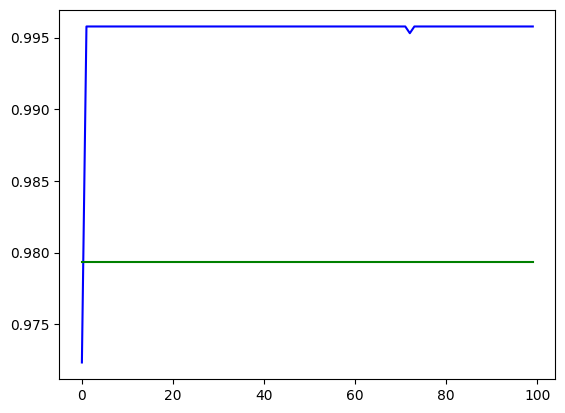

In [304]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="accuracy",color ="blue")
plt.plot(history.history["val_accuracy"],label="val_a",color="green")

In [270]:
data['buy'].value_counts()


buy
0    3897
1      58
Name: count, dtype: int64

In [271]:
print(data['buy'].value_counts(normalize=True))


buy
0    0.985335
1    0.014665
Name: proportion, dtype: float64


In [272]:
print(data2.columns)


Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'priceOpen',
       'priceHigh', 'priceLow', 'priceClose', 'volume', 'return', 'ma_5',
       'buy'],
      dtype='object')


In [233]:
print(data.columns)


Index(['snapped_at', 'price', 'market_cap', 'total_volume', 'return', 'ma_5',
       'buy'],
      dtype='object')
